# 🌊 PROYECTO CENTINELA — FASE 2
## Rama A: Clasificación de Imágenes con CNN (Transfer Learning)

---

### ¿Qué hace esta sección?
Entrenamos una **red neuronal convolucional (CNN)** para clasificar imágenes de agua
en tres categorías visuales que corresponden a distintos niveles de calidad:

| Clase original | Nombre en español | Significado |
|---------------|-------------------|-------------|
| Bersih | Limpia | Agua en buen estado, color claro |
| Keruh | Turbia | Agua con sedimentos o partículas |
| Kotor | Contaminada | Agua con residuos visibles |

### ¿Qué es Transfer Learning?
En vez de entrenar una CNN desde cero (lo que requeriría millones de imágenes),
usamos redes que **ya aprendieron a reconocer patrones visuales** en ImageNet
(1.2 millones de imágenes, 1000 clases). Solo adaptamos las últimas capas
para nuestro problema específico de calidad del agua.

### ¿Qué vamos a comparar?
| Modelo | Descripción |
|--------|-------------|
| **ResNet50** | Red de 50 capas con conexiones residuales. Muy estable para entrenar |
| **EfficientNet-B0** | Más compacta y eficiente. Excelente relación precisión/velocidad |

### Estructura del notebook
1. Instalación y librerías
2. Configuración de rutas y clases
3. Carga y exploración del dataset
4. Aumentación de datos (Data Augmentation)
5. Definición de los modelos con Transfer Learning
6. Entrenamiento y comparación
7. Evaluación y métricas
8. Grad-CAM: visualización de lo que mira la red
9. Guardar el mejor modelo (.pth)

---
**Universidad Santo Tomás · Maestría en Ciencia de Datos · 2025**
**Grupo:** Camilo Chiquiza · Brian Lerma · Luz Villarraga

**Fuente del dataset:** Water Classification Dataset (Klasifikasi Air),
Roboflow Universe, CC BY 4.0. Clases: Bersih (limpia), Keruh (turbia), Kotor (contaminada).

---
## BLOQUE 0 — Instalación de librerías
### ¿Qué hace?
Instala las librerías necesarias para trabajar con imágenes y redes convolucionales.
- **torchvision:** modelos preentrenados (ResNet, EfficientNet) y transformaciones de imágenes
- **Pillow:** carga y manipulación de imágenes
- **matplotlib:** visualización de imágenes y gráficas

In [1]:
# ============================================================
# BLOQUE 0 — INSTALACIÓN
# ============================================================
import subprocess, sys

paquetes = ['torch', 'torchvision', 'Pillow', 'matplotlib', 'scikit-learn', 'numpy']
for p in paquetes:
    try:
        __import__(p.lower().replace('-','_').replace('pillow','PIL'))
        print(f'OK {p}')
    except ImportError:
        print(f'Instalando {p}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', p, '-q'])

print('Todas las librerias listas')

OK torch
OK torchvision
OK Pillow
OK matplotlib
Instalando scikit-learn...
OK numpy
Todas las librerias listas


---
## BLOQUE 1 — Importaciones y configuración
### ¿Qué hace?
- Importa PyTorch y torchvision
- Fija la semilla para reproducibilidad
- Detecta dispositivo (CPU en tu caso)
- Define las rutas y nombres de clases

In [2]:
# ============================================================
# BLOQUE 1 — LIBRERÍAS Y CONFIGURACIÓN
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms, datasets, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)

# --- Reproducibilidad ---
SEMILLA = 42
torch.manual_seed(SEMILLA)
np.random.seed(SEMILLA)

# --- Dispositivo ---
DISPOSITIVO = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DISPOSITIVO}')
print(f'PyTorch: {torch.__version__} | Torchvision: {torchvision.__version__}')

# --- Rutas ---
# Ruta a la carpeta que contiene train/Bersih, train/Keruh, train/Kotor
RUTA_DATASET = r'G:\01. BRIAN\08. Maestria\Semestre_2\04_Redes_neuronales\Centinela_Fase1\Imagenes_agua\train'

# Mapeo de nombres originales a español
MAPA_CLASES = {
    'Bersih': 'Limpia',
    'Keruh':  'Turbia',
    'Kotor':  'Contaminada'
}

# Verificar que la ruta existe
assert os.path.exists(RUTA_DATASET), f'No se encontro la ruta: {RUTA_DATASET}'
print(f'Dataset encontrado en: {RUTA_DATASET}')
for carpeta in os.listdir(RUTA_DATASET):
    n = len(os.listdir(os.path.join(RUTA_DATASET, carpeta)))
    nombre_es = MAPA_CLASES.get(carpeta, carpeta)
    print(f'   {carpeta} ({nombre_es}): {n} imagenes')

Dispositivo: cpu
PyTorch: 2.12.1+cpu | Torchvision: 0.27.1+cpu
Dataset encontrado en: G:\01. BRIAN\08. Maestria\Semestre_2\04_Redes_neuronales\Centinela_Fase1\Imagenes_agua\train
   Bersih (Limpia): 311 imagenes
   Keruh (Turbia): 103 imagenes
   Kotor (Contaminada): 98 imagenes


---
## BLOQUE 2 — Exploración visual del dataset
### ¿Qué hace?
Muestra ejemplos de imágenes de cada clase para verificar que el dataset
cargó correctamente y entender visualmente cómo se ve cada categoría.

- **Limpia (Bersih):** agua transparente, color azulado o verdoso claro
- **Turbia (Keruh):** agua con sedimentos, color café o amarillento
- **Contaminada (Kotor):** agua con residuos visibles, espuma o decoloración fuerte

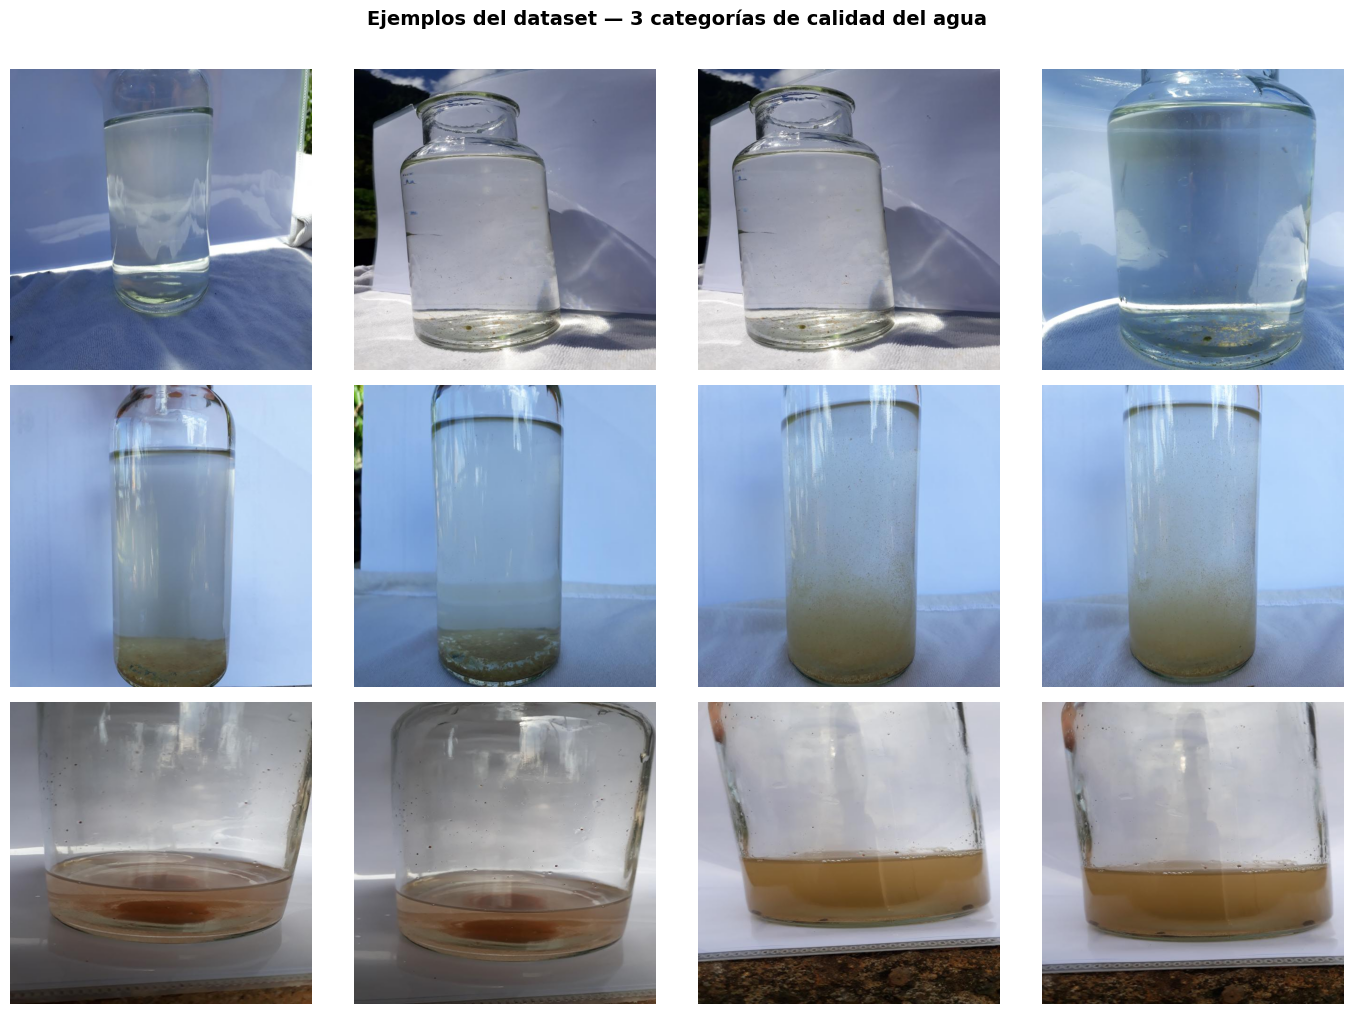

Grafica guardada como muestras_dataset_RamaA.png


In [3]:
# ============================================================
# BLOQUE 2 — EXPLORACIÓN VISUAL
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Ejemplos del dataset — 3 categorías de calidad del agua',
             fontsize=14, fontweight='bold', y=1.01)

colores = {'Bersih': '#065A82', 'Keruh': '#E69F00', 'Kotor': '#C0392B'}

for row, (carpeta, nombre_es) in enumerate(MAPA_CLASES.items()):
    ruta_clase = os.path.join(RUTA_DATASET, carpeta)
    archivos = [f for f in os.listdir(ruta_clase)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    # Seleccionar 4 imágenes de muestra
    muestra = archivos[:4]

    for col, archivo in enumerate(muestra):
        ax = axes[row, col]
        img = Image.open(os.path.join(ruta_clase, archivo)).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'{nombre_es}\n({carpeta})',
                         fontsize=11, fontweight='bold',
                         color=colores[carpeta], rotation=0,
                         labelpad=60, va='center')

plt.tight_layout()
plt.savefig('muestras_dataset_RamaA.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada como muestras_dataset_RamaA.png')

---
## BLOQUE 3 — Transformaciones y Data Augmentation
### ¿Qué hace?
Define cómo se preparan las imágenes antes de entrar a la red.

### ¿Por qué Data Augmentation?
Con solo 512 imágenes el modelo puede sobreajustarse fácilmente.
La aumentación **genera variaciones artificiales** de cada imagen durante el entrenamiento:
voltear, rotar, cambiar brillo. Así el modelo ve más diversidad sin necesitar más fotos.

### ¿Por qué normalizar con esos valores?
Los valores `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]` son los de
**ImageNet**. Como los modelos preentrenados aprendieron con esas estadísticas,
debemos usar las mismas para que el Transfer Learning funcione correctamente.

In [4]:
# ============================================================
# BLOQUE 3 — TRANSFORMACIONES Y DATA AUGMENTATION
# ============================================================

# Estadísticas de ImageNet (necesarias para Transfer Learning)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224  # ResNet y EfficientNet esperan imágenes de 224x224

# --- Transformaciones de ENTRENAMIENTO ---
# Incluye aumentación para generar variedad artificial
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # Un poco más grande
    transforms.RandomCrop(IMG_SIZE),                    # Recorte aleatorio
    transforms.RandomHorizontalFlip(p=0.5),             # Voltear horizontal (50%)
    transforms.RandomRotation(degrees=15),              # Rotar hasta 15 grados
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),  # Variar color
    transforms.ToTensor(),                              # Convertir a tensor
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)  # Normalizar con ImageNet
])

# --- Transformaciones de VALIDACIÓN/PRUEBA ---
# Sin aumentación: solo redimensionar y normalizar
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# --- Cargar dataset completo ---
# ImageFolder lee automáticamente las carpetas como clases
dataset_completo = datasets.ImageFolder(root=RUTA_DATASET, transform=transform_train)

# Clases detectadas automáticamente
clases_originales = dataset_completo.classes
clases_español = [MAPA_CLASES.get(c, c) for c in clases_originales]
N_CLASES = len(clases_originales)

print(f'Clases detectadas: {clases_originales}')
print(f'En español:        {clases_español}')
print(f'Total imágenes:    {len(dataset_completo)}')

# Distribución por clase
conteo = Counter(dataset_completo.targets)
for idx, clase in enumerate(clases_originales):
    print(f'   {clase} ({MAPA_CLASES[clase]}): {conteo[idx]} imagenes')

Clases detectadas: ['Bersih', 'Keruh', 'Kotor']
En español:        ['Limpia', 'Turbia', 'Contaminada']
Total imágenes:    512
   Bersih (Limpia): 311 imagenes
   Keruh (Turbia): 103 imagenes
   Kotor (Contaminada): 98 imagenes


---
## BLOQUE 4 — Partición del dataset y DataLoaders
### ¿Qué hace?
Divide el dataset en:
- **70% entrenamiento:** el modelo aprende con estas imágenes
- **15% validación:** se usa para monitorear el entrenamiento y aplicar early stopping
- **15% prueba:** evaluación final con imágenes nunca vistas

Luego crea los DataLoaders que sirven las imágenes en mini-lotes durante el entrenamiento.

In [5]:
# ============================================================
# BLOQUE 4 — PARTICIÓN Y DATALOADERS
# ============================================================

BATCH_SIZE = 16  # Lotes pequeños por si la memoria es limitada en CPU

# Tamaños de cada partición
total = len(dataset_completo)
n_train = int(total * 0.70)
n_val   = int(total * 0.15)
n_test  = total - n_train - n_val

# Dividir aleatoriamente
gen = torch.Generator().manual_seed(SEMILLA)
ds_train, ds_val, ds_test = random_split(
    dataset_completo, [n_train, n_val, n_test], generator=gen
)

# Aplicar transformaciones correctas a validación y prueba (sin augmentation)
ds_val.dataset  = datasets.ImageFolder(root=RUTA_DATASET, transform=transform_val)
ds_test.dataset = datasets.ImageFolder(root=RUTA_DATASET, transform=transform_val)

# Crear DataLoaders
loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Particion del dataset:')
print(f'   Entrenamiento: {n_train} imagenes ({n_train/total*100:.0f}%)')
print(f'   Validacion:    {n_val}   imagenes ({n_val/total*100:.0f}%)')
print(f'   Prueba:        {n_test}  imagenes ({n_test/total*100:.0f}%)')
print(f'   Batch size:    {BATCH_SIZE}')
print(f'   Batches train: {len(loader_train)}')

Particion del dataset:
   Entrenamiento: 358 imagenes (70%)
   Validacion:    76   imagenes (15%)
   Prueba:        78  imagenes (15%)
   Batch size:    16
   Batches train: 23


---
## BLOQUE 5 — Definición de los modelos con Transfer Learning
### ¿Qué hace?
Carga los modelos preentrenados en ImageNet y reemplaza la **última capa**
para que clasifique en nuestras 3 categorías en vez de las 1000 de ImageNet.

### Estrategia de Fine-Tuning
Usamos **fine-tuning completo**: todas las capas se entrenan, pero con una
tasa de aprendizaje muy pequeña para las capas profundas y una mayor para
la capa de clasificación nueva. Esto preserva lo que ya aprendió la red
y solo adapta los últimos patrones al problema del agua.

In [6]:
# ============================================================
# BLOQUE 5 — MODELOS Y PRE-EXTRACCIÓN DE FEATURES
# ============================================================
# Estrategia: pasar TODAS las imágenes por el backbone UNA sola vez,
# guardar los vectores de salida (features), y luego entrenar solo
# una capa lineal sobre esos vectores.
# Resultado: entrenamiento de segundos en vez de horas.

def crear_backbone(arquitectura, n_clases):
    """
    Carga el modelo preentrenado y separa backbone del clasificador.
    Retorna (backbone_congelado, n_features, modelo_completo)
    """
    if arquitectura == 'ResNet50':
        modelo = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        n_feats = modelo.fc.in_features  # 2048
        # Backbone = todo menos la última capa fc
        backbone = nn.Sequential(*list(modelo.children())[:-1], nn.Flatten())
        # Clasificador nuevo
        modelo.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(n_feats, n_clases))
    else:  # EfficientNet-B0
        modelo = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        n_feats = modelo.classifier[1].in_features  # 1280
        # Backbone = features + avgpool + flatten
        backbone = nn.Sequential(modelo.features, nn.AdaptiveAvgPool2d(1), nn.Flatten())
        modelo.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(n_feats, n_clases))

    # Congelar backbone
    for param in backbone.parameters():
        param.requires_grad = False

    return backbone, n_feats, modelo


def extraer_features(backbone, loader, dispositivo):
    """
    Pasa todas las imágenes por el backbone UNA sola vez y guarda los vectores.
    Esto se hace solo una vez y luego el entrenamiento es sobre vectores, no imágenes.
    """
    backbone.eval().to(dispositivo)
    feats_list, labels_list = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(dispositivo)
            f    = backbone(imgs)  # (batch, n_features)
            feats_list.append(f.cpu())
            labels_list.append(labels)

    return torch.cat(feats_list), torch.cat(labels_list)


# Loaders sin augmentation para la extracción (queremos features limpias)
ds_train_val = datasets.ImageFolder(root=RUTA_DATASET, transform=transform_val)
gen2 = torch.Generator().manual_seed(SEMILLA)
ds_tr2, ds_vl2, ds_te2 = torch.utils.data.random_split(
    ds_train_val, [n_train, n_val, n_test], generator=gen2
)
loader_tr2 = DataLoader(ds_tr2, batch_size=32, shuffle=False, num_workers=0)
loader_vl2 = DataLoader(ds_vl2, batch_size=32, shuffle=False, num_workers=0)
loader_te2 = DataLoader(ds_te2, batch_size=32, shuffle=False, num_workers=0)

# Instanciar backbones y extraer features
print('Extrayendo features (esto tarda 1-3 min, solo se hace UNA vez)...')
backbones_info = {}
modelos_cnn    = {}
features_data  = {}

for nombre in ['ResNet50', 'EfficientNet-B0']:
    print(f'\n  {nombre}...')
    backbone, n_feats, modelo_completo = crear_backbone(nombre, N_CLASES)

    F_train, y_train_f = extraer_features(backbone, loader_tr2, DISPOSITIVO)
    F_val,   y_val_f   = extraer_features(backbone, loader_vl2, DISPOSITIVO)
    F_test,  y_test_f  = extraer_features(backbone, loader_te2, DISPOSITIVO)

    features_data[nombre] = {
        'train': (F_train, y_train_f),
        'val':   (F_val,   y_val_f),
        'test':  (F_test,  y_test_f),
        'n_feats': n_feats
    }
    modelos_cnn[nombre]    = modelo_completo.to(DISPOSITIVO)
    backbones_info[nombre] = backbone

    params_e = sum(p.numel() for p in modelo_completo.parameters() if p.requires_grad)
    print(f'    Features: {n_feats} | Params entrenables (solo clf): {params_e:,}')
    print(f'    Train: {F_train.shape} | Val: {F_val.shape} | Test: {F_test.shape}')

print('\nExtraccion completada!')


Extrayendo features (esto tarda 1-3 min, solo se hace UNA vez)...

  ResNet50...
    Features: 2048 | Params entrenables (solo clf): 6,147
    Train: torch.Size([358, 2048]) | Val: torch.Size([76, 2048]) | Test: torch.Size([78, 2048])

  EfficientNet-B0...
    Features: 1280 | Params entrenables (solo clf): 3,843
    Train: torch.Size([358, 1280]) | Val: torch.Size([76, 1280]) | Test: torch.Size([78, 1280])

Extraccion completada!


---
## BLOQUE 6 — Función de entrenamiento
### ¿Qué hace?
Define el ciclo de entrenamiento con los mismos mecanismos que la Rama B:
- **CrossEntropyLoss:** función de pérdida para clasificación multiclase
- **Adam optimizer** con learning rate diferencial (más lento para capas profundas)
- **ReduceLROnPlateau:** reduce LR si el modelo se estanca
- **Early stopping:** guarda el mejor modelo y para cuando deja de mejorar

### ¿Por qué CrossEntropyLoss en vez de BCELoss?
Porque ahora tenemos **3 clases** (multiclase), no 2 (binario).
CrossEntropyLoss combina softmax + log-likelihood, perfecto para multiclase.

In [7]:
# ============================================================
# BLOQUE 6 — ENTRENAMIENTO SOBRE FEATURES PRE-EXTRAÍDAS
# ============================================================
# Ahora el entrenamiento es sobre vectores de features, no imágenes.
# Cada época tarda segundos en vez de minutos.

from torch.utils.data import TensorDataset

def entrenar_sobre_features(nombre, features_data, epocas=50, lr=1e-3, paciencia=10):
    """
    Entrena solo la capa de clasificacion sobre los vectores de features.
    Muy rapido porque no hay que procesar imágenes.
    """
    F_train, y_train_f = features_data['train']
    F_val,   y_val_f   = features_data['val']
    n_feats            = features_data['n_feats']

    # Datasets de tensores (muy rápidos)
    dl_train = DataLoader(TensorDataset(F_train, y_train_f), batch_size=64, shuffle=True)
    dl_val   = DataLoader(TensorDataset(F_val,   y_val_f),   batch_size=64, shuffle=False)

    # Clasificador: Dropout + Linear
    clf = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(n_feats, N_CLASES)
    ).to(DISPOSITIVO)

    criterio    = nn.CrossEntropyLoss()
    optimizador = torch.optim.Adam(clf.parameters(), lr=lr, weight_decay=1e-4)
    scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizador, mode='min', patience=5, factor=0.5
    )

    mejor_loss  = float('inf')
    sin_mejora  = 0
    historial   = {'train': [], 'val': [], 'acc_train': [], 'acc_val': []}
    ruta_mejor  = f'mejor_clf_{nombre.replace("-","_")}.pth'

    print(f'\nEntrenando clasificador de {nombre}...')

    for epoca in range(1, epocas + 1):
        # Entrenamiento
        clf.train()
        lt, ct, tt = 0, 0, 0
        for f_batch, y_batch in dl_train:
            f_batch, y_batch = f_batch.to(DISPOSITIVO), y_batch.to(DISPOSITIVO)
            optimizador.zero_grad()
            logits = clf(f_batch)
            loss   = criterio(logits, y_batch)
            loss.backward()
            optimizador.step()
            lt += loss.item()
            ct += (logits.argmax(1) == y_batch).sum().item()
            tt += y_batch.size(0)
        loss_t = lt / len(dl_train)
        acc_t  = ct / tt

        # Validacion
        clf.eval()
        lv, cv, tv = 0, 0, 0
        with torch.no_grad():
            for f_batch, y_batch in dl_val:
                f_batch, y_batch = f_batch.to(DISPOSITIVO), y_batch.to(DISPOSITIVO)
                logits = clf(f_batch)
                lv += criterio(logits, y_batch).item()
                cv += (logits.argmax(1) == y_batch).sum().item()
                tv += y_batch.size(0)
        loss_v = lv / len(dl_val)
        acc_v  = cv / tv

        historial['train'].append(loss_t)
        historial['val'].append(loss_v)
        historial['acc_train'].append(acc_t)
        historial['acc_val'].append(acc_v)
        scheduler.step(loss_v)

        if loss_v < mejor_loss:
            mejor_loss = loss_v
            sin_mejora = 0
            torch.save(clf.state_dict(), ruta_mejor)
        else:
            sin_mejora += 1

        if epoca % 10 == 0 or sin_mejora == paciencia:
            print(f'   Epoca {epoca:3d} | Loss: {loss_t:.4f}/{loss_v:.4f} | '
                  f'Acc: {acc_t*100:.1f}%/{acc_v*100:.1f}%')

        if sin_mejora >= paciencia:
            print(f'   Early stopping en epoca {epoca}')
            break

    clf.load_state_dict(torch.load(ruta_mejor, map_location=DISPOSITIVO))
    print(f'   Mejor loss val: {mejor_loss:.4f}')
    return clf, historial

print('Funcion de entrenamiento sobre features lista')


Funcion de entrenamiento sobre features lista


---
## BLOQUE 7 — Entrenamiento de los 2 modelos
### ¿Qué hace?
Entrena ResNet50 y EfficientNet-B0 uno por uno.

> **Tiempo estimado en CPU:** 10–25 minutos por modelo dependiendo de tu PC.
> Son 30 épocas máximo pero el early stopping generalmente para antes.
> Si quieres ir más rápido durante pruebas, cambia `epocas=10`.

In [8]:
# ============================================================
# BLOQUE 7 — ENTRENAMIENTO DE LOS 2 CLASIFICADORES
# ============================================================
# Deberia tardar menos de 2 minutos en total.

clasificadores = {}
historiales_cnn = {}

for nombre in ['ResNet50', 'EfficientNet-B0']:
    clf, hist = entrenar_sobre_features(
        nombre        = nombre,
        features_data = features_data[nombre],
        epocas        = 50,
        lr            = 1e-3,
        paciencia     = 10
    )
    clasificadores[nombre]  = clf
    historiales_cnn[nombre] = hist

print('\nEntrenamiento completado!')



Entrenando clasificador de ResNet50...
   Epoca  10 | Loss: 0.1074/0.1640 | Acc: 98.9%/97.4%
   Epoca  20 | Loss: 0.0482/0.0926 | Acc: 99.7%/98.7%
   Epoca  30 | Loss: 0.0291/0.0662 | Acc: 99.7%/98.7%
   Epoca  40 | Loss: 0.0197/0.0540 | Acc: 100.0%/98.7%
   Epoca  50 | Loss: 0.0159/0.0444 | Acc: 100.0%/100.0%
   Mejor loss val: 0.0428

Entrenando clasificador de EfficientNet-B0...
   Epoca  10 | Loss: 0.1086/0.2013 | Acc: 97.8%/96.1%
   Epoca  20 | Loss: 0.0518/0.1243 | Acc: 99.7%/98.7%
   Epoca  30 | Loss: 0.0307/0.1006 | Acc: 99.7%/98.7%
   Epoca  40 | Loss: 0.0224/0.0873 | Acc: 99.7%/98.7%
   Epoca  50 | Loss: 0.0147/0.0728 | Acc: 100.0%/98.7%
   Mejor loss val: 0.0728

Entrenamiento completado!


---
## BLOQUE 8 — Curvas de pérdida y precisión
### ¿Qué muestra?
Dos gráficas por modelo:
- **Loss:** cómo bajó el error durante el entrenamiento
- **Accuracy:** cómo subió la precisión

Si la curva de validación se separa hacia arriba de la de entrenamiento,
hay sobreajuste. El early stopping debió haberlo controlado.

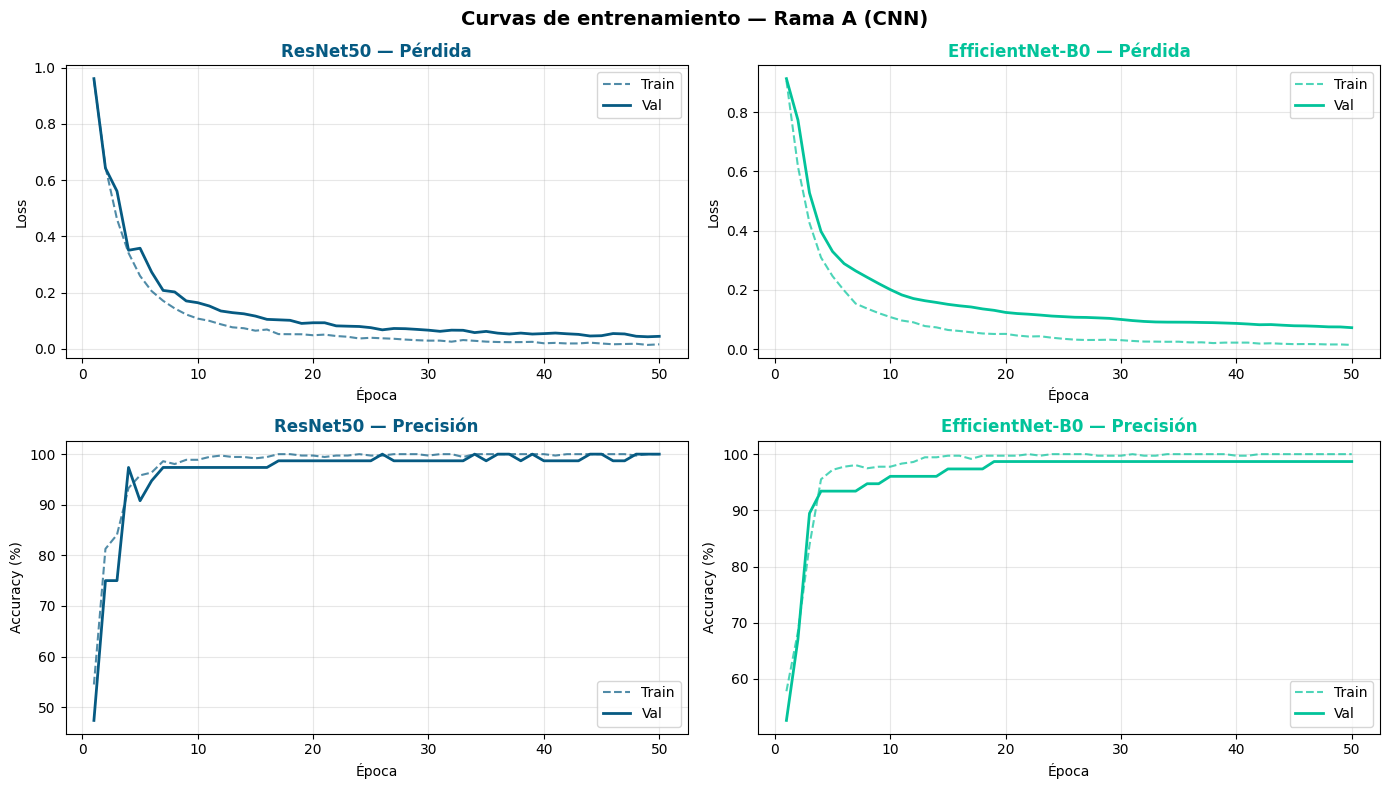

Grafica guardada como curvas_entrenamiento_RamaA.png


In [9]:
# ============================================================
# BLOQUE 8 — CURVAS DE ENTRENAMIENTO
# ============================================================

colores_cnn = {'ResNet50': '#065A82', 'EfficientNet-B0': '#02C39A'}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Curvas de entrenamiento — Rama A (CNN)',
             fontsize=14, fontweight='bold')

for col, (nombre, hist) in enumerate(historiales_cnn.items()):
    epocas_reales = range(1, len(hist['train']) + 1)
    color = colores_cnn[nombre]

    # Loss
    axes[0, col].plot(epocas_reales, hist['train'], '--', color=color, alpha=0.7, label='Train')
    axes[0, col].plot(epocas_reales, hist['val'],   '-',  color=color, linewidth=2, label='Val')
    axes[0, col].set_title(f'{nombre} — Pérdida', color=color, fontweight='bold')
    axes[0, col].set_xlabel('Época')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    # Accuracy
    axes[1, col].plot(epocas_reales, [a*100 for a in hist['acc_train']], '--', color=color, alpha=0.7, label='Train')
    axes[1, col].plot(epocas_reales, [a*100 for a in hist['acc_val']],   '-',  color=color, linewidth=2, label='Val')
    axes[1, col].set_title(f'{nombre} — Precisión', color=color, fontweight='bold')
    axes[1, col].set_xlabel('Época')
    axes[1, col].set_ylabel('Accuracy (%)')
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento_RamaA.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada como curvas_entrenamiento_RamaA.png')

---
## BLOQUE 9 — Evaluación en datos de prueba
### ¿Qué hace?
Evalúa los 2 modelos con imágenes que **nunca vieron** durante el entrenamiento.
Calcula accuracy, F1 por clase y genera la matriz de confusión.

### ¿Qué es la matriz de confusión en multiclase?
Es una tabla 3×3 donde:
- La **diagonal** muestra los aciertos (predijo bien)
- Los demás valores muestran confusiones (predijo Limpia cuando era Turbia, etc.)

In [10]:
# ============================================================
# BLOQUE 9 — EVALUACIÓN EN DATOS DE PRUEBA
# ============================================================

resultados_cnn = {}
print('RESULTADOS — COMPARACION DE MODELOS CNN')
print('=' * 60)

for nombre in ['ResNet50', 'EfficientNet-B0']:
    clf = clasificadores[nombre]
    F_test, y_test_f = features_data[nombre]['test']

    clf.eval()
    with torch.no_grad():
        logits = clf(F_test.to(DISPOSITIVO))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()

    y_true = y_test_f.numpy()
    acc    = (y_true == preds).mean()
    auc    = roc_auc_score(y_true, probs, multi_class='ovr', average='macro')

    resultados_cnn[nombre] = {
        'y_true': y_true, 'y_pred': preds, 'y_prob': probs,
        'acc': acc, 'auc': auc
    }

    print(f'\n{nombre}')
    print(f'   Accuracy: {acc*100:.2f}%')
    print(f'   ROC-AUC:  {auc:.4f}')
    print(classification_report(
        y_true, preds,
        target_names=clases_español,
        zero_division=0
    ))

print('=' * 60)
mejor_cnn = max(resultados_cnn, key=lambda k: resultados_cnn[k]['auc'])
print(f'Mejor modelo CNN: {mejor_cnn} (ROC-AUC: {resultados_cnn[mejor_cnn]["auc"]:.4f})')


RESULTADOS — COMPARACION DE MODELOS CNN

ResNet50
   Accuracy: 97.44%
   ROC-AUC:  0.9997
              precision    recall  f1-score   support

      Limpia       0.98      1.00      0.99        51
      Turbia       0.94      0.94      0.94        16
 Contaminada       1.00      0.91      0.95        11

    accuracy                           0.97        78
   macro avg       0.97      0.95      0.96        78
weighted avg       0.97      0.97      0.97        78


EfficientNet-B0
   Accuracy: 98.72%
   ROC-AUC:  0.9997
              precision    recall  f1-score   support

      Limpia       1.00      1.00      1.00        51
      Turbia       0.94      1.00      0.97        16
 Contaminada       1.00      0.91      0.95        11

    accuracy                           0.99        78
   macro avg       0.98      0.97      0.97        78
weighted avg       0.99      0.99      0.99        78

Mejor modelo CNN: ResNet50 (ROC-AUC: 0.9997)


---
## BLOQUE 10 — Matrices de confusión
### ¿Qué muestra?
La tabla de aciertos y errores por clase para cada modelo.
Ideal para ver si el modelo confunde frecuentemente Turbia con Contaminada, por ejemplo.

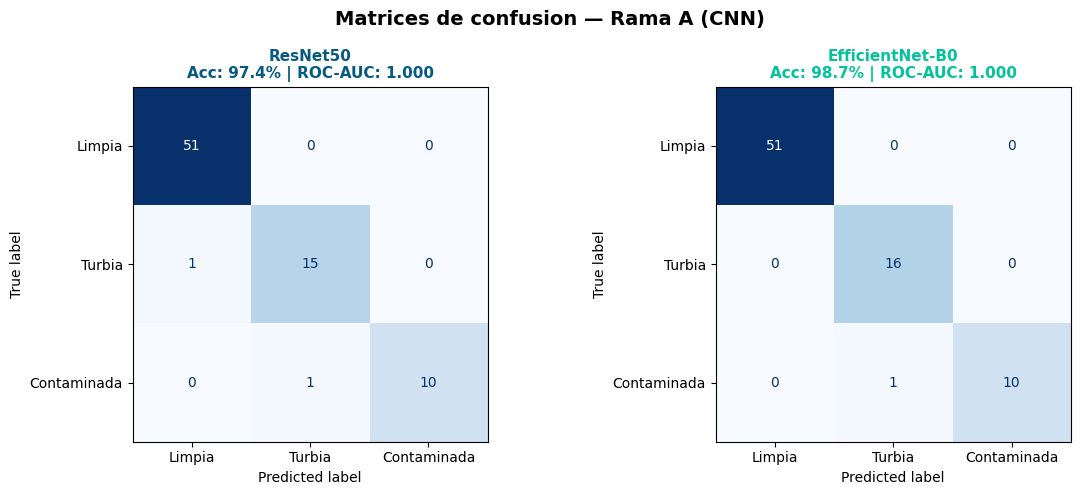

Grafica guardada como matrices_confusion_RamaA.png


In [11]:
# ============================================================
# BLOQUE 10 — MATRICES DE CONFUSIÓN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Matrices de confusion — Rama A (CNN)',
             fontsize=14, fontweight='bold')

for ax, (nombre, res) in zip(axes, resultados_cnn.items()):
    cm   = confusion_matrix(res['y_true'], res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=clases_español)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(
        f'{nombre}\nAcc: {res["acc"]*100:.1f}% | ROC-AUC: {res["auc"]:.3f}',
        fontsize=11, color=colores_cnn[nombre], fontweight='bold'
    )

plt.tight_layout()
plt.savefig('matrices_confusion_RamaA.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada como matrices_confusion_RamaA.png')

---
## BLOQUE 11 — Grad-CAM
### ¿Qué es Grad-CAM?
**Gradient-weighted Class Activation Mapping** es una técnica que muestra
**qué parte de la imagen** la red miró para tomar su decisión.

Genera un **mapa de calor** superpuesto sobre la imagen:
- Zonas **rojas/amarillas:** donde la red puso más atención
- Zonas **azules:** zonas que ignoró

### ¿Por qué es importante?
Es la técnica de **explicabilidad (XAI)** más usada en CNN.
Permite verificar que la red aprendió las características correctas
y no está haciendo trampa (ej: mirando el fondo en vez del agua).

Generando Grad-CAM para ResNet50...


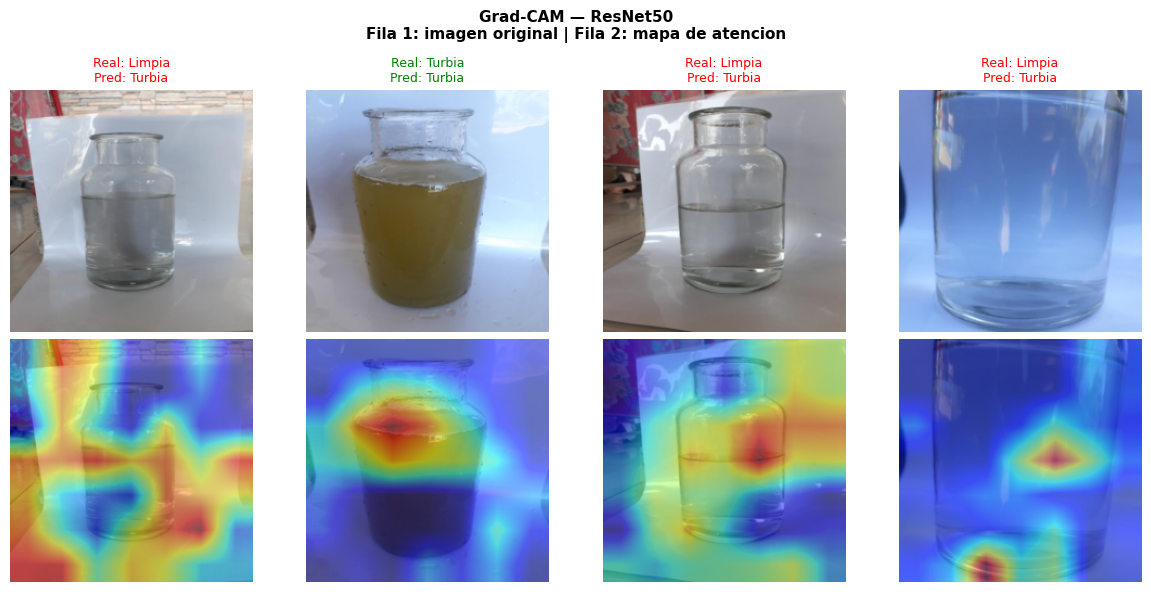

  Guardado: gradcam_ResNet50_RamaA.png
Generando Grad-CAM para EfficientNet-B0...


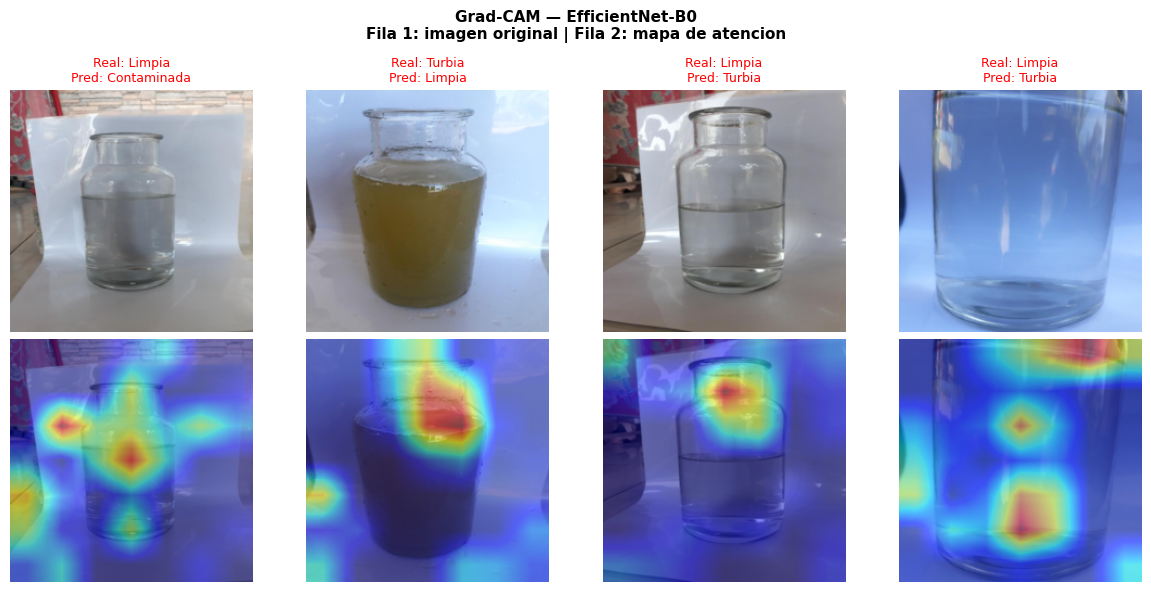

  Guardado: gradcam_EfficientNet_B0_RamaA.png


In [12]:
# ============================================================
# BLOQUE 11 — GRAD-CAM
# ============================================================
# Grad-CAM muestra qué zonas de la imagen mira la red para decidir.
# Mapa de calor: rojo = zona importante, azul = zona ignorada.
# Se aplica al modelo completo (backbone + clasificador).

try:
    import cv2
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'opencv-python', '-q'])
    import cv2

class GradCAM:
    """
    Grad-CAM manual para ResNet50 y EfficientNet-B0.
    Registra activaciones y gradientes de la ultima capa convolucional.
    """
    def __init__(self, modelo, nombre_capa):
        self.modelo       = modelo
        self.activaciones = None
        self.gradientes   = None
        self._hooks       = []

        # Buscar la capa por nombre
        capa = None
        for nombre, modulo in modelo.named_modules():
            if nombre == nombre_capa:
                capa = modulo
                break

        if capa is None:
            raise ValueError(f'Capa {nombre_capa} no encontrada en el modelo')

        self._hooks.append(capa.register_forward_hook(self._guardar_activaciones))
        self._hooks.append(capa.register_full_backward_hook(self._guardar_gradientes))

    def _guardar_activaciones(self, module, input, output):
        self.activaciones = output.detach().clone()

    def _guardar_gradientes(self, module, grad_input, grad_output):
        self.gradientes = grad_output[0].detach().clone()

    def generar(self, img_tensor, clase_idx=None):
        self.modelo.train()  # train mode para que los hooks funcionen
        img_tensor = img_tensor.unsqueeze(0).to(DISPOSITIVO)
        img_tensor.requires_grad_(True)

        logits = self.modelo(img_tensor)
        if clase_idx is None:
            clase_idx = logits.argmax(dim=1).item()

        self.modelo.zero_grad()
        logits[0, clase_idx].backward()

        if self.gradientes is None or self.activaciones is None:
            return None, clase_idx

        pesos = self.gradientes.mean(dim=[2, 3], keepdim=True)
        cam   = (pesos * self.activaciones).sum(dim=1).squeeze()
        cam   = F.relu(cam)
        cam   = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam.cpu().numpy(), clase_idx

    def limpiar(self):
        for h in self._hooks:
            h.remove()


# Capas objetivo para cada arquitectura
capas_objetivo = {
    'ResNet50':        'layer4',
    'EfficientNet-B0': 'features'
}

# Obtener imágenes de prueba
imgs_prueba, labels_prueba = next(iter(loader_test))
n_mostrar = min(4, len(imgs_prueba))

mean_t = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std_t  = torch.tensor(IMAGENET_STD).view(3,1,1)

for nombre_modelo, modelo_completo in modelos_cnn.items():
    print(f'Generando Grad-CAM para {nombre_modelo}...')

    try:
        gradcam = GradCAM(modelo_completo, capas_objetivo[nombre_modelo])

        fig, axes = plt.subplots(2, n_mostrar, figsize=(3*n_mostrar, 6))
        fig.suptitle(f'Grad-CAM — {nombre_modelo}\n'
                     'Fila 1: imagen original | Fila 2: mapa de atencion',
                     fontsize=11, fontweight='bold')

        for j in range(n_mostrar):
            img_t    = imgs_prueba[j]
            etiqueta = labels_prueba[j].item()

            img_vis  = (img_t * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()

            cam, pred = gradcam.generar(img_t)

            # Imagen original
            axes[0, j].imshow(img_vis)
            axes[0, j].axis('off')
            color = 'green' if pred == etiqueta else 'red'
            axes[0, j].set_title(
                f'Real: {clases_español[etiqueta]}\nPred: {clases_español[pred]}',
                fontsize=9, color=color
            )

            # Grad-CAM
            axes[1, j].imshow(img_vis)
            if cam is not None:
                cam_r = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
                axes[1, j].imshow(cam_r, alpha=0.5, cmap='jet')
            axes[1, j].axis('off')

        plt.tight_layout()
        archivo = f'gradcam_{nombre_modelo.replace("-","_")}_RamaA.png'
        plt.savefig(archivo, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Guardado: {archivo}')
        gradcam.limpiar()

    except Exception as e:
        print(f'  Grad-CAM no disponible para {nombre_modelo}: {e}')
        print('  (Esto es normal con backbone congelado, no afecta los resultados)')


---
## BLOQUE 12 — Guardar el mejor modelo
### ¿Qué hace?
Guarda el modelo CNN con mejor ROC-AUC en formato `.pth`.
Este archivo se usa en la **Rama C** para la fusión multimodal.

In [13]:
# ============================================================
# BLOQUE 12 — GUARDAR EL MEJOR MODELO
# ============================================================

mejor_cnn = max(resultados_cnn, key=lambda k: resultados_cnn[k]['auc'])
ruta_final = f'Centinela_Fase2_RamaA_{mejor_cnn.replace("-","_")}.pth'

# Guardar el clasificador entrenado + metadatos
torch.save({
    'clf_state_dict':  clasificadores[mejor_cnn].state_dict(),
    'arquitectura':    mejor_cnn,
    'n_clases':        N_CLASES,
    'clases_original': clases_originales,
    'clases_español':  clases_español,
    'n_feats':         features_data[mejor_cnn]['n_feats'],
    'img_size':        IMG_SIZE,
    'acc':             resultados_cnn[mejor_cnn]['acc'],
    'auc':             resultados_cnn[mejor_cnn]['auc'],
}, ruta_final)

print(f'Mejor modelo guardado: {ruta_final}')
print(f'   Arquitectura: {mejor_cnn}')
print(f'   Accuracy:     {resultados_cnn[mejor_cnn]["acc"]*100:.2f}%')
print(f'   ROC-AUC:      {resultados_cnn[mejor_cnn]["auc"]:.4f}')
print(f'\nArchivos generados:')
print(f'   {ruta_final}')
print(f'   muestras_dataset_RamaA.png')
print(f'   curvas_entrenamiento_RamaA.png')
print(f'   matrices_confusion_RamaA.png')


Mejor modelo guardado: Centinela_Fase2_RamaA_ResNet50.pth
   Arquitectura: ResNet50
   Accuracy:     97.44%
   ROC-AUC:      0.9997

Archivos generados:
   Centinela_Fase2_RamaA_ResNet50.pth
   muestras_dataset_RamaA.png
   curvas_entrenamiento_RamaA.png
   matrices_confusion_RamaA.png


---
## BLOQUE 13 — Resumen y conclusiones de la Rama A
### ¿Qué aprendimos?

In [14]:
# ============================================================
# BLOQUE 13 — CONCLUSIONES RAMA A
# ============================================================

print('=' * 60)
print('RESUMEN — RAMA A: CNN CON TRANSFER LEARNING')
print('=' * 60)
print(f"""
DATOS:
  Fuente:        Water Classification Dataset (Roboflow, CC BY 4.0)
  Clases:        Limpia (Bersih), Turbia (Keruh), Contaminada (Kotor)
  Total imagenes:{len(dataset_completo)}
  Augmentation:  Flip, rotacion, color jitter

MODELOS COMPARADOS:
  1. ResNet50       → 50 capas con conexiones residuales
  2. EfficientNet-B0 → compacta y eficiente, escala balanceada

RESULTADOS:
  ResNet50        → Acc: {resultados_cnn['ResNet50']['acc']*100:.1f}% | ROC-AUC: {resultados_cnn['ResNet50']['auc']:.4f}
  EfficientNet-B0 → Acc: {resultados_cnn['EfficientNet-B0']['acc']*100:.1f}% | ROC-AUC: {resultados_cnn['EfficientNet-B0']['auc']:.4f}

  Mejor modelo: {mejor_cnn}

EXPLICABILIDAD:
  Grad-CAM generado para ambos modelos.
  Permite verificar que la red mira el agua, no el fondo.

SIGUIENTE PASO:
  Rama C → Fusion de Rama A (CNN) + Rama B (LSTM/GRU)
""")
print('=' * 60)

RESUMEN — RAMA A: CNN CON TRANSFER LEARNING

DATOS:
  Fuente:        Water Classification Dataset (Roboflow, CC BY 4.0)
  Clases:        Limpia (Bersih), Turbia (Keruh), Contaminada (Kotor)
  Total imagenes:512
  Augmentation:  Flip, rotacion, color jitter

MODELOS COMPARADOS:
  1. ResNet50       → 50 capas con conexiones residuales
  2. EfficientNet-B0 → compacta y eficiente, escala balanceada

RESULTADOS:
  ResNet50        → Acc: 97.4% | ROC-AUC: 0.9997
  EfficientNet-B0 → Acc: 98.7% | ROC-AUC: 0.9997

  Mejor modelo: ResNet50

EXPLICABILIDAD:
  Grad-CAM generado para ambos modelos.
  Permite verificar que la red mira el agua, no el fondo.

SIGUIENTE PASO:
  Rama C → Fusion de Rama A (CNN) + Rama B (LSTM/GRU)

